# EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Setup

Loaded `results` from `data/processed/` (feature-enriched table with
`position_change`, `era`, and `year` already built in notebook 02).
Recast `position` to nullable `Int64` to restore dtype lost in CSV
round-trip.

Filtered to `results_finished_gridded` (5,337 rows): excludes 1,039
DNF rows where `position` is null and 85 pit lane starts where
`grid == 0`. Overlap of 25 rows that were both pit lane starters and
DNFs accounts for the difference from the naive sum of 1,124. Original
`results` (6,436 rows) preserved for charts that need the full picture.


In [21]:
# Load results from data/processed (has position_change and era already built)
results = pd.read_csv('../data/processed/results.csv')
team_season = pd.read_csv('../data/processed/team_season.csv')

In [3]:
# recast position to Int64
results['position'] = results['position'].astype('Int64')

In [6]:
# get rid of the rows where position is NaN (DNF) and Pit lane starts out (grid == 0) get rid of them 
results_finished_gridded = results[(results['position'].notna()) & (results['grid'] != 0)].copy()

## Chart 1: Grid Position vs Finishing Position

**Purpose:** Establish whether starting grid position predicts finishing
position, and whether that relationship has shifted across the four eras.
A strong relationship suggests the field order set in qualifying largely
held through the race. A weak relationship suggests drivers or strategy
moved people around.

This chart does not assign cause. A strong grid-to-finish relationship
could reflect car dominance, driver consistency, or limited overtaking
opportunities on modern circuits. It sets the baseline that the teammate
gap and position change charts build on.

**Bias and documentation notes:**
- DNFs excluded because finishing position is undefined for
non-finishers. Consequence: early eras with higher DNF rates (~17.7%)
are underrepresented relative to later eras (~12%).
- Pit lane starts excluded because `grid = 0` is a code not a position.
- Sample sizes are structurally imbalanced across eras
(1,810 / 2,827 / 440 / 1,359). The 2021 era is one season only and
its visual cloud will be smaller.
- Correlation is not causation. Interpretation belongs in the write-up
alongside the chart, not in the chart title.


In [9]:
results_finished_gridded.columns

Index(['raceId', 'driverId', 'constructorId', 'grid', 'position',
       'positionText', 'points', 'statusId', 'position_change', 'year', 'era'],
      dtype='object')

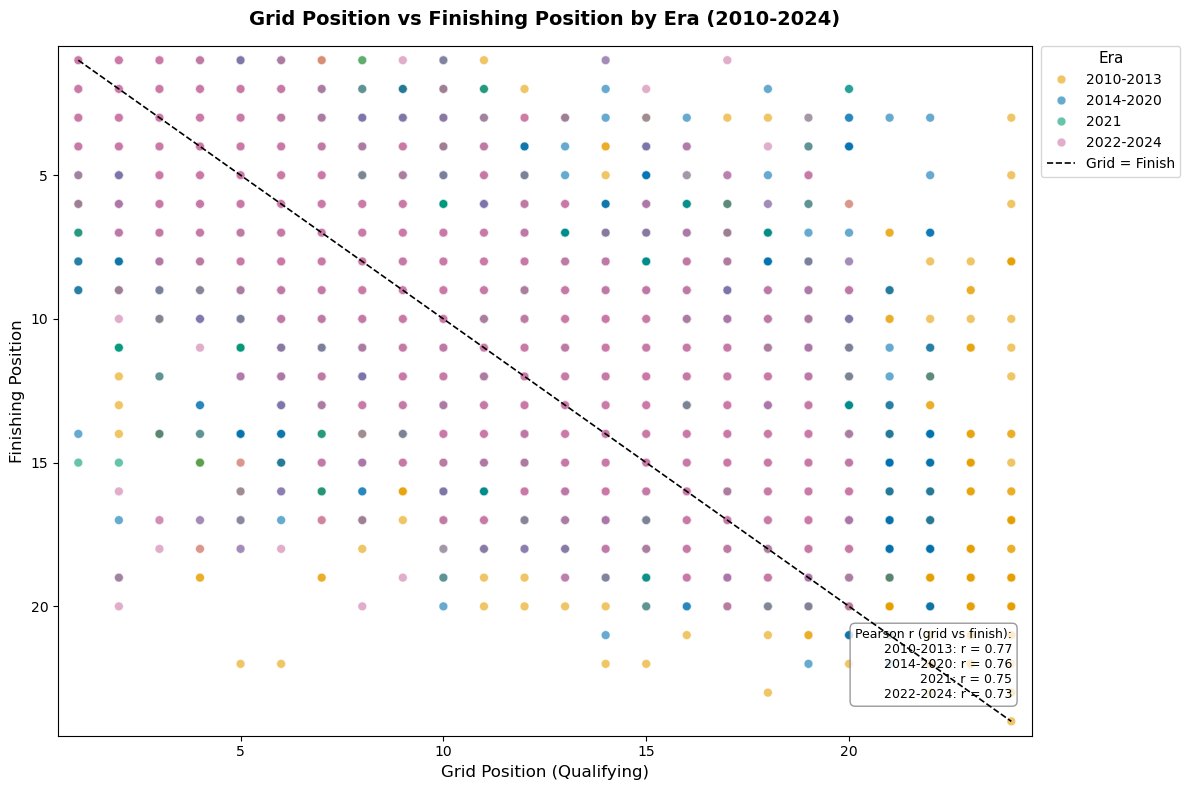

In [18]:
# Colorblind-friendly palette (Wong 2011, widely used in academic publishing)
era_palette = {
    '2010-2013': '#E69F00',   # orange
    '2014-2020': '#0072B2',   # blue
    '2021':      '#009E73',   # green
    '2022-2024': '#CC79A7'    # pink/mauve
}

fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=results_finished_gridded,
    x='grid',
    y='position',
    hue='era',
    palette=era_palette,
    alpha=0.6,
    s=40,
    ax=ax
)

# Diagonal reference line: grid = finish (perfect prediction)
ax.plot([1, 24], [1, 24], color='black', linewidth=1.2, 
        linestyle='--', label='Grid = Finish', zorder=5)

# Invert y-axis: P1 at top
ax.invert_yaxis()

# Axis limits: F1 has max 24 starters in this window
ax.set_xlim(0.5, 24.5)
ax.set_ylim(24.5, 0.5)

# Correlation annotation per era
eras = ['2010-2013', '2014-2020', '2021', '2022-2024']
colors = ['#E69F00', '#0072B2', '#009E73', '#CC79A7']
annotation_lines = []

for era, color in zip(eras, colors):
    subset = results_finished_gridded[results_finished_gridded['era'] == era]
    corr = subset['grid'].corr(subset['position'])
    annotation_lines.append(f"{era}: r = {corr:.2f}")

annotation_text = "Pearson r (grid vs finish):\n" + "\n".join(annotation_lines)

ax.text(
    0.98, 0.05,
    annotation_text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='grey', alpha=0.8)
)

ax.set_title(
    'Grid Position vs Finishing Position by Era (2010-2024)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Grid Position (Qualifying)', fontsize=12)
ax.set_ylabel('Finishing Position', fontsize=12)

# Legend outside the plot on the right
ax.legend(
    title='Era',
    title_fontsize=11,
    fontsize=10,
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0
)

plt.tight_layout()
plt.savefig('../visualizations/chart1_grid_vs_finish.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 1: Grid Position vs Finishing Position by Era (2010-2024)

### What this chart is asking
Does where you start predict where you finish?
This is the first question we need to answer before anything else.
If starting position completely determines the result, the car and
qualifying pace did all the work. If drivers are regularly finishing
far away from where they started, something else is happening during
the race, whether that is driver skill, team strategy, or both.

### How to read this chart
Every dot is one driver in one race.
- The bottom axis (left to right) shows where they started: P1
on the left, P24 on the right.
- The left axis (top to bottom) shows where they finished: P1
at the top, P24 at the bottom.
- The black dashed line is the "nothing changed" reference line.
A dot sitting exactly on it means that driver started and finished
in the same position.
- Dots above the line: the driver finished worse than they started.
They lost places during the race.
- Dots below the line: the driver finished better than they started.
They gained places during the race.

### What Pearson r means in plain English
The numbers in the bottom right corner (r = 0.77, 0.76, 0.75, 0.73)
measure how strongly grid position predicted finishing position in
each era. Think of it like a score from 0 to 1:
- 1.0 would mean every driver finished exactly where they started,
every single race.
- 0.0 would mean starting position told you absolutely nothing
about where someone would finish.
- Our numbers sit around 0.75, which means grid position is a
meaningful predictor but nowhere near the whole story.
There is real movement happening during races across all four eras.

### What this chart is actually telling us
Grid position consistently predicted finishing position across all
15 seasons, but it never locked the result in completely. The wide
scatter of dots away from the diagonal line shows that positions
changed regularly during races. Drivers who started near the back
sometimes finished near the front, and drivers who started up front
sometimes fell back.

Importantly, the relationship barely changed across eras. The r value
only dropped from 0.77 to 0.73 over 15 years. This tells us the
baseline grip of starting position on race outcomes has been
remarkably stable, even as regulations, cars, and dominant teams
changed dramatically.

### What this chart does NOT tell us
A strong grid-to-finish relationship does not automatically mean
the car did all the work. It could mean the driver who qualified
well also races well. It could mean modern circuits make overtaking
difficult. This chart establishes the baseline. The teammate gap
and position change charts that follow will start to separate
what is car, what is driver, and what is strategy.

### Important caveats
- DNFs are excluded (1,039 rows). Drivers who did not finish have
no finishing position. Early eras had higher DNF rates (~17.7%)
than later eras (~12%), so early eras may be slightly
underrepresented in the scatter.
- 2021 is one season only (440 rows). Its color cloud is smaller
than the others, not because less happened that year, but because
there were simply fewer races to draw from. Treat 2021 visually
as a single data point, not a full era pattern.
- The four eras have very different numbers of races behind them
(4 seasons, 7 seasons, 1 season, 3 seasons). The visual density
of each color is not a fair comparison of how often things
happened, just of how many races exist in each era.

### What comes next
This chart sets up two follow-up questions:
- Who is actually gaining those positions during races?
(Chart 2: position change by era)
- Is the gap between teammates on the same car getting bigger
or smaller across eras?
(Chart 3: teammate gap by era)

## Chart 2: Position Change Distribution by Era (2010-2024)

### What this chart is asking
When drivers move during a race, how much do they move?
And has that changed across eras?

`position_change` is grid position minus finishing position.
A positive number means the driver gained places during the race.
A negative number means they lost places.
Zero means they finished exactly where they started.

This chart zooms in on the movement that chart 1 showed us
was happening. Instead of plotting every individual race,
it shows the full distribution of position changes in each
era so we can compare: which eras had the most movement,
and which eras were the most locked in?

### Why eras and not individual years
F1 does not change gradually. It changes in jumps, when
regulations reset, when a new engine formula drops, when
one team figures out something nobody else has. Grouping
by era lets us ask whether the balance between driver skill
and team strategy shifted when the competitive landscape
shifted. Each era represents a different dominant force and
a different set of conditions. Flattening 15 years into one
number would hide those jumps entirely.

### How to read this chart
Each shape is one era. The wider the shape at any point,
the more drivers finished with that position change in
that era. The white dot in the middle is the median.
The thin black bar shows the middle 50% of results.
The lines extending out show the full range, excluding
extreme outliers.

- A shape centered above zero means drivers in that era
tended to gain places on average.
- A shape centered below zero means drivers tended to
lose places.
- A tall narrow shape means most drivers had similar
position changes, the field was locked in.
- A wide flat shape means position changes were all over
the place, lots of movement happening.

### Bias and documentation notes
- Same filtered frame as chart 1: DNFs and pit lane starts
excluded (5,337 rows). Position change is null for those
rows and would be skipped automatically, but using the
same consistent frame keeps the two charts comparable.
- Sample sizes are unbalanced across eras (1,810 / 2,827 /
440 / 1,359). The violin shape is not affected by count
the way a bar chart would be, it shows distribution shape
regardless of sample size. But the 2021 violin is built
from one season only and should be interpreted carefully.
- Position change captures race movement only. It does not
capture how a driver got there: whether it was pure
overtaking skill, a well-timed pit stop call, or a rival
retirement. It is a proxy, not a perfect measure.

### What comes next
If certain eras show wider distributions with more positive
position changes, that points toward driver skill mattering
more in those eras. That finding feeds directly into the
t-tests we run after the five charts are done.

/var/folders/v2/9k8drrwj5h39kpr935vvx6j80000gn/T/ipykernel_89641/305575400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


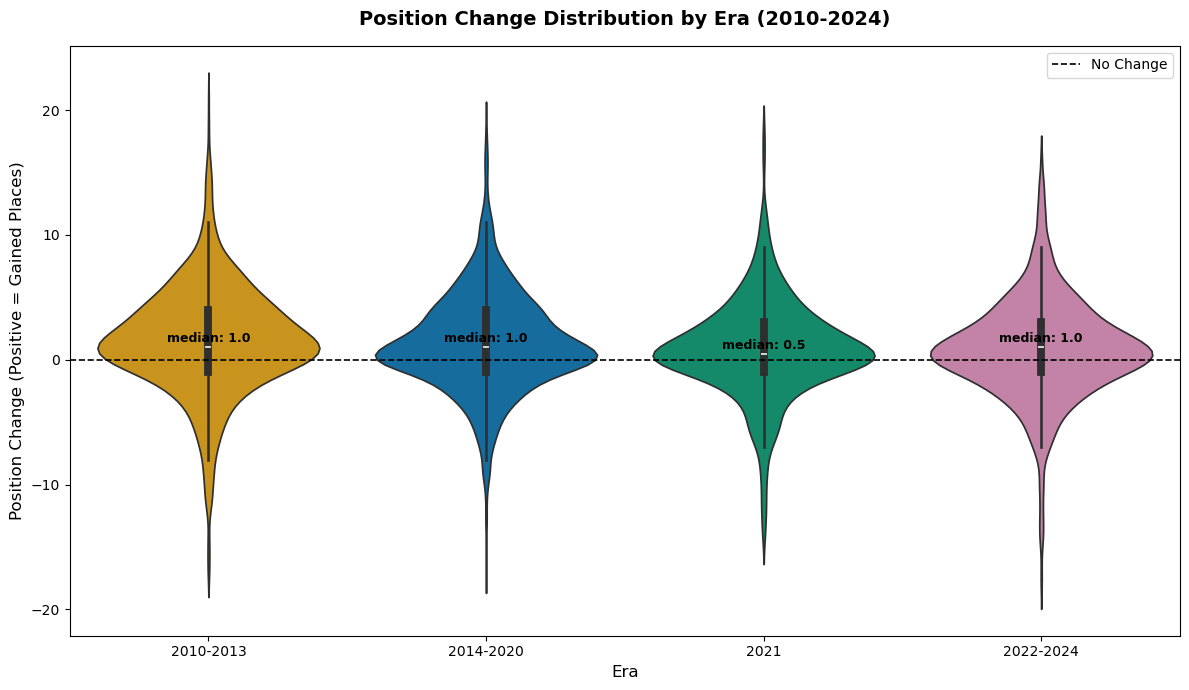

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.violinplot(
    data=results_finished_gridded,
    x='era',
    y='position_change',
    palette=era_palette,
    inner='box',
    ax=ax
)

# Reference line at zero: no position change
ax.axhline(y=0, color='black', linewidth=1.2, linestyle='--', label='No Change')

ax.set_title(
    'Position Change Distribution by Era (2010-2024)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Era', fontsize=12)
ax.set_ylabel('Position Change (Positive = Gained Places)', fontsize=12)

ax.legend(fontsize=10)

# Median annotation per era
era_order = ['2010-2013', '2014-2020', '2021', '2022-2024']
for i, era in enumerate(era_order):
    median = results_finished_gridded[
        results_finished_gridded['era'] == era
    ]['position_change'].median()
    ax.text(
        i, median + 0.4,
        f'median: {median:.1f}',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.savefig('../visualizations/chart2_position_change_by_era.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 2: Position Change Distribution by Era (2010-2024)

### What this chart is asking
Chart 1 showed us that drivers do move around during races.
This chart zooms into that movement and asks: how much do
drivers actually move, and did that change across eras?

### How to read this chart
Imagine asking every driver after their race: did you finish
better or worse than where you started? This chart is 5,337
of those answers, sorted into four piles by era.

- The fat middle part of each shape is where most answers
landed. The wider the shape, the more drivers had that
exact result.
- The skinny tail stretching up is the rare hero drive:
someone started 18th and finished 3rd.
- The skinny tail stretching down is the rare disaster:
someone started 3rd and finished 18th.
- The dashed line at zero means finished exactly where
you started.

### What median 1.0 means
If you lined up every driver's position change from worst
to best, the driver exactly in the middle gained 1 place.
Half of all drivers did better than that, half did worse.
Three eras have a median of 1.0 and 2021 has 0.5. In plain
terms: the typical driver in every era gained about one
place during a race.

### What this chart is telling us
All four piles look almost identical. The typical race in
2012 looked like the typical race in 2023: gain a spot or
two, occasionally a hero drive, occasionally a disaster.

That flatness is the finding. The cars changed completely,
the regulations reset twice, and different teams dominated
each era. Yet how much drivers move during a race stayed
the same. When something stays flat while everything around
it changes, that is information.

### Why this matters for the research question
This chart closes a door. The difference between eras does
NOT live in raw race movement. If driver skill or team
strategy shifted in importance across eras, the evidence
must live somewhere else: in the gap between teammates in
the same car, or in pit stop execution. The next charts go
looking there.

### One more job this chart does
The shapes are roughly symmetric around their middle, with
no wild lopsidedness. That matters because the statistical
tests planned for later (t-tests comparing eras) assume
roughly symmetric data. This chart is the visual evidence
that those tests are valid to run.

### Caveats
- Same filtered data as chart 1: DNFs and pit lane starts
excluded (5,337 rows kept).
- 2021 is one season (440 rows) versus multiple seasons for
every other era. Its shape is drawn from less data, which
is why it looks slightly compressed. Read it carefully,
not as a full era pattern.
- Position change measures where drivers ended up, not how
they got there. A gained place could be an overtake, a
smart pit call, or a rival breaking down. It is a proxy,
not a perfect measure of driver skill.

In [25]:
team_season.head()

,constructorId,year,points_high,points_low,teammate_gap
0,1,2010,240.0,214.0,26.0
1,1,2011,270.0,227.0,43.0
2,1,2012,190.0,188.0,2.0
3,1,2013,73.0,49.0,24.0
4,1,2014,126.0,55.0,71.0
